# Computation on NumPy Arrays

## Chapters 6-12

## The slowness of loops

The default implementatio of Python (known an CPython) performs some operations __very slowly__.

This is partly due to the interpreted nature of the language that allows flexible types and renders efficient compilation to machine code impossible.

Python can be especially slow when small operations are being repeated on large inputs. For instance, looping over arrays to operate on each element.

For example, suppose we have an array of values and we would like to comute the _reciprocal_ (`1/x`) for each value `x`. A straightforward implementation would be:

In [ ]:
import numpy as np
rng = np.random.default_rng(seed=1701)

def compute_reciprocals(values):
    output = np.empty(len(values))
    for i in range(len(values)):
        output[i] = 1.0/values[i]
    return output


values = rng.integers(1, 10, size=5)
compute_reciprocals(values)

The above implementation may feel very natural to someone from a C or Java background. However, it is surprisingly slow in Python.

Let us measure the execution time with `%timeit` magic on a very large input:

In [ ]:
big_array = rng.integers(1, 100, size=10000000)

%timeit compute_reciprocals(big_array)

The reason the above operation is slow is mainly due to the type checking Python must do after each calculation.
Indeed, after each loop cycle, Python examines the object's type and performs a lookup of the function to run for that type. If the code was compiled instead of interpreted, this specificaiton would have been known before runtime and would run much faster.

## Introducing Ufuncs

NumPy provides a convenient interface to statically typed arrays. Known as __vectorized__ operations.

For simple operations, like element-wise division, vectorization is as simple as using Python arithmetic. Indeed, NumPy _overloads_ many of Python's operators to perform vectorized computations on arrays.

To compute reciprocals on a NumPy array, we would just use `1.0/values`. This would perform an element-wise division on the entire array and produce another array with the results:

In [ ]:
print(compute_reciprocals(values))
print(1.0/values)

Let us time the runtime of reciprocals using vectorized division:

In [ ]:
%timeit (1.0/big_array)

__How much faster is the above implementation when compared to the loop-based one?__

Vectorized operations are implemented via _ufuncs_.

Before we saw an operation between a scalar and an array, but we can also operate between two arrays:

In [ ]:
np.arange(5) / np.arange(1, 6)

Ufunc operations also work on multidimensional arrays:

In [ ]:
x = np.arange(9).reshape((3, 3))
print(2**x)

__Exercise__: Create a program that initializes a 4x4 matrix `a` containing all ones, a `4x4` identity matrix `i`, and produces a matrix containing the element-wise subtraction of `i` from `a`. You must use vectorized operations to do this.

In [ ]:
# Answer:
a = np.ones((4,4))
i = np.eye(4)
print(a - i)

## Array arithmetic

NumPy's ufuncs feel very natural to use because they overload Python's native operators:

In [ ]:
x = np.arange(4)
print("x      =", x)
print("x + 5  =", x + 5)
print("x - 5  =", x - 5)
print("x * 2  =", x * 2)
print("x / 2  =", x / 2)
print("x // 2 =", x // 2)  # floor division
print("-x     = ", -x)
print("x ** 2 = ", x ** 2)
print("x % 2  = ", x % 2)

You can also write compound expression using array arithmetic:

In [ ]:
-(0.5*x + 1) ** 2

__Remember__: Arithmetic operators are just interfaces, convenient ways, to use functions. You can also invoke NumPy ufuncs using their real name:

In [ ]:
# Repeating the operations from above but using ufunc calls instead of arithmetic operators.

print("x      =", x)
print("x + 5  =", np.add(x, 5))
print("x - 5  =", np.subtract(x, 5))
print("x * 2  =", np.multiply(x, 2))
print("x / 2  =", np.divide(x, 2))
print("x // 2 =", np.floor_divide(x, 2))  # floor division
print("-x     = ", np.negative(x))
print("x ** 2 = ", np.power(x, 2))
print("x % 2  = ", np.mod(x, 2))

### Absolute value

Python's built-in function `abs` compute the absolute value of a number. The corresponding NumPy ufunc is `np.absolute` or the shorthand `np.abs`:

In [ ]:
x = np.array([-2, -1, 0, 1, 2])
print(np.absolute(x))

### Trigonometric ufuncs

NumPy implements a number of trigonometric functions:

In [ ]:
theta = np.linspace(0, np.pi, 3)


In [ ]:
# Angles sine, cosine, tangent

print("theta      = ", theta)
print("sin(theta) = ", np.sin(theta))
print("cos(theta) = ", np.cos(theta))
print("tan(theta) = ", np.tan(theta))

In [ ]:
# Inverse trigonometric functions

x = [-1, 0, 1]
print("x         = ", x)
print("arcsin(x) = ", np.arcsin(x))
print("arccos(x) = ", np.arccos(x))
print("arctan(x) = ", np.arctan(x))

### Element-wise vs matrix multiplication

The multiplication operator `*` when applied to NumPy arrays performs _element-wise_ multiplication. This means the result is the product of each element pair of the input arrays.

On the other hand, to perform _matrix multiplication_, you can use `@`:

In [ ]:
x = np.array([[1,2], [3,4]])
y = np.array([[2,2], [3,3]])

print(x*y)

In [ ]:
print(x@y)

## Chapter 7. Aggregations: min, max and everything in between

When exploring datasets, it is often useful to compute various summary statistics. The most common ones might be the _mean_ and _standard deviation_.

NumPy implements fast aggregation functions to work on arrays.

### Array sum

Python has a built-in `sum` function, but NumPy's `np.sum` is much faster:

In [ ]:
big_array = rng.random(1000000)

%timeit sum(big_array)
%timeit np.sum(big_array)

### Minimum and maximum values

Python's built-in `min` and `max` functions correspond to NumPy's `np.min` and `np.max`. The latter implementations are much faster.

In [ ]:
np.min(big_array), np.max(big_array)

## Multidimensional aggregates

Aggregating multidimensional arrays can be applied in three ways: to all elements in the array, along rows, or along columns.

If unspecified, aggregations will __apply across all elements of a multidimensional array__:

In [ ]:
M = rng.integers(0, 10, (3, 4))

print(M)

print(M.sum())

#### Axis

Aggregation functions take an additional argument, called `axis`. This argument specifies the dimension along which the aggregation is computed. For example, to find the minimum value within each _column_, we specify `axis=0`:

In [ ]:
print(M.min(axis=0))  # Finds the minimum of each column

Similarly, we can find the maximum value of each row:

In [ ]:
print(M.max(axis=1))

__Note__: The way `axis` is specified can be confusing. The keyword specifies the dimension of the array that will be _collapsed_ rather than the dimension that will be returned. Specifying `axis=0` means that __each row__ will be collapsed (aggregated) into a single number.

## Chapter 8. Broadcasting

_Broadcasting_ is a set of rules by which NumPy facilitates vectorized operations.

For __arrays of the same size__, binary operations are performed on an __element-by-element__ basis:

In [ ]:
a = np.array([0, 1, 2])
b = np.array([5, 5, 5])
a + b

Broadcasting also works with a vector and a scalar:

In [ ]:
a + 5

We can think of the above as an operation that _stretches_ scalar `5` into an array with `[5, 5, 5]`.

This idea can be extended to higher dimensions. Observe the result when adding a one-dimensional array to a two-dimensional array:

In [ ]:
M = np.ones((3, 3))
M

In [ ]:
M + a

Here is a visualization of broadcasting in NumPy:

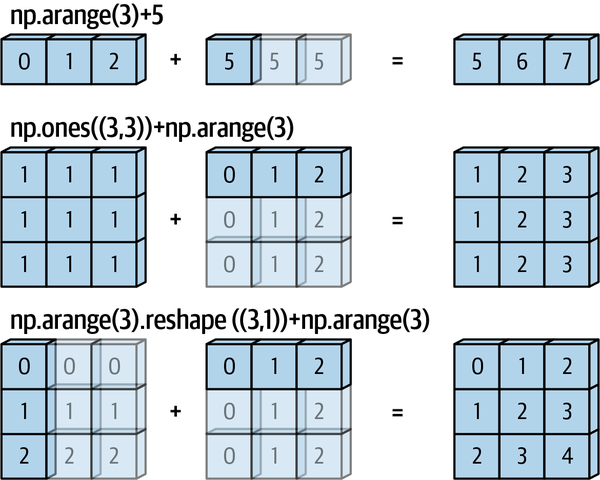

In [ ]:
x = np.arange(9).reshape(3,3)
y = np.arange(3) + 1
y = y.reshape(3,1)
print(x)
print(y)
print('---')
print(x+y)

## Chapter 9. Comparisons, masks and boolean logic

In this chapter, we will cover comparisons as vectorized operations, vector masks and boolean logic.

### Comparison operators and Ufuncs

Similarly to artichmetic operators, comparison operators (such as `<` and `>`) are implemented in NumPy as Ufuncs. The result of a vectorized comparison operation is an array of _Booleans_:

In [ ]:
x = np.array([1,2,3,4,5])

In [ ]:
x < 3

In [ ]:
x > 3

In [ ]:
x <= 3

In [ ]:
x != 3

In [ ]:
x == 3

Like with arithmetic operators, comparisons can be applied to multidimensional arrays:

In [ ]:
x = rng.integers(10, size=(3, 4))
x

In [ ]:
x < 6

### Counting results

Boolean values are treated as 0 if `False` or 1 if `True`. We can use this to _count_ the number of specific observations in an array by _summing_ the resulting Boolean values.

For instance, we can count how many elements of `x` are less than 5:

In [ ]:
b_mask = x < 5
print(b_mask)

print(f"The number of elements less than 5 is {b_mask.sum()}")


### Boolean arrays as masks

We can use Boolean arrays as masks to retrieve a subset of a NumPy array. Let us take a look at array `x` from above:

In [ ]:
print(x)

Suppose we want to filter all the values in `x` that are less than 5.
This can be easily done with:

In [ ]:
x < 5

To effectively select these values from the array, we use the Boolean array from above to index `x`. This procedure is known as _masking_:

In [ ]:
mask = x < 100
x[mask]

# Exercises

Give the output of the following programs:

In [ ]:
# 1.

m = np.ones(10)
m = 2*m
print(m.sum())

In [ ]:
# 2.
m = np.ones(4)
n = np.ones(4).reshape(4,1)
print(n-m)

In [ ]:
# 3.

m = np.arange(9).reshape(3,3)
print(m.sum(axis=0))